# Student Performance Prediction — Linear Regression with Gradient Descent

**Dataset:** UCI Student Performance Data Set (`student-mat.csv` + `student-por.csv`)
**Target:** `G3` — final grade (0–20)

This notebook:
1. Loads and merges the Math and Portuguese student datasets
2. Preprocesses the data (missing values, categorical encoding, feature scaling)
3. Selects input features and target
4. Splits into train/test sets
5. Implements Linear Regression trained with **Batch, Mini-Batch, and Stochastic Gradient
   Descent** (pure NumPy, `theta`-vector formulation), following the same structure as the
   reference notebook
6. Experiments with different learning rates and plots Loss vs. Iterations
7. Visualizes the Gradient Descent path on a 3D cost surface (illustrative single-feature view)
8. Evaluates the final model with MAE, MSE, RMSE, R²
9. Interprets the results


### Step 1: Import Libraries

- `numpy` for numerical operations, especially array/matrix manipulation.
- `matplotlib.pyplot` and `mpl_toolkits.mplot3d` for visualizations, including the 3D cost
  surface.
- `pandas` to load and merge the two CSV files.
- `sklearn.model_selection.train_test_split` to create train/test sets.
- `sklearn.preprocessing.StandardScaler` to standardize features — important for gradient
  descent performance.
- `sklearn.metrics` for the final MAE / MSE / RMSE / R² evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RNG_SEED = 42
np.random.seed(RNG_SEED)
%matplotlib inline


### Step 2: Load the Student Performance Dataset

- Loads `student-mat.csv` and `student-por.csv` (semicolon-separated).
- Tags each with its `course` of origin and concatenates them into a single DataFrame.
- `X` will ultimately hold our (multi-feature) independent variables, `y` = `G3`, the final
  grade — analogous to how the reference notebook loads `diabetes.data` / `diabetes.target`.

In [2]:
mat = pd.read_csv("student-mat.csv", sep=";")
por = pd.read_csv("student-por.csv", sep=";")

mat["course"] = "Math"
por["course"] = "Portuguese"

df = pd.concat([mat, por], axis=0, ignore_index=True)

print("student-mat.csv :", mat.shape)
print("student-por.csv :", por.shape)
print("Combined dataset :", df.shape)
df.head()


student-mat.csv : (395, 34)
student-por.csv : (649, 34)
Combined dataset : (1044, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Math


### Step 3: Data Preprocessing

**Missing values:** the UCI dataset is generally clean, but we check for and defensively
handle missing values anyway (numeric columns → median, categorical columns → mode).

**Categorical encoding:**
- Binary categoricals (yes/no, F/M, U/R, etc.) → label-encoded to 0/1
- Nominal categoricals with more than two categories (Mjob, Fjob, reason, guardian, course)
  → one-hot encoded

In [3]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None found.")

num_cols_all = df.select_dtypes(include=[np.number]).columns
cat_cols_all = df.select_dtypes(include=["object"]).columns
df[num_cols_all] = df[num_cols_all].fillna(df[num_cols_all].median())
df[cat_cols_all] = df[cat_cols_all].fillna(df[cat_cols_all].mode().iloc[0])

binary_cols = ["school", "sex", "address", "famsize", "Pstatus", "schoolsup",
               "famsup", "paid", "activities", "nursery", "higher", "internet",
               "romantic"]
nominal_cols = ["Mjob", "Fjob", "reason", "guardian", "course"]

df_enc = df.copy()
for col in binary_cols:
    df_enc[col] = df_enc[col].astype("category").cat.codes

df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=True)
df_enc.head()


Missing values per column:
None found.


/tmp/ipykernel_536/202217434.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_all = df.select_dtypes(include=["object"]).columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,course_Portuguese
0,0,0,18,1,0,0,4,4,2,2,...,False,False,False,True,False,False,False,True,False,False
1,0,0,17,1,0,1,1,1,1,2,...,False,True,False,False,False,False,False,False,False,False
2,0,0,15,1,1,1,1,1,1,2,...,False,True,False,False,False,True,False,True,False,False
3,0,0,15,1,0,1,4,2,1,3,...,False,False,True,False,True,False,False,True,False,False
4,0,0,16,1,0,1,3,3,1,2,...,False,True,False,False,True,False,False,False,False,False


### Step 4: Select Input Features and Target

**Target:** `G3` (final grade)

We deliberately **exclude `G1` and `G2`** (the two period grades) from the feature set —
they are near-duplicates of `G3` and would trivially inflate performance. Instead we predict
the final grade from demographic, family, and study-habit features only, which is a more
meaningful regression problem (similar in spirit to the reference notebook using a single
BMI feature to predict diabetes progression — here we use the full feature set instead of
just one).

In [4]:
target_col = "G3"
drop_cols = ["G1", "G2", target_col]
feature_cols = [c for c in df_enc.columns if c not in drop_cols]

X = df_enc[feature_cols].astype(float).values
y = df_enc[target_col].astype(float).values

print(f"Feature matrix: {X.shape[1]} features, {X.shape[0]} samples")
feature_cols


Feature matrix: 40 features, 1044 samples


['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'Mjob_health',
 'Mjob_other',
 'Mjob_services',
 'Mjob_teacher',
 'Fjob_health',
 'Fjob_other',
 'Fjob_services',
 'Fjob_teacher',
 'reason_home',
 'reason_other',
 'reason_reputation',
 'guardian_mother',
 'guardian_other',
 'course_Portuguese']

### Step 5: Train/Test Split and Feature Scaling

80/20 split. As in the reference notebook, we fit `StandardScaler` and scale the features
before running gradient descent — this is crucial for stable, fast convergence, since raw
features here live on very different scales (e.g. `age` vs. binary 0/1 columns).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RNG_SEED
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Add bias (intercept) column, and reshape y into a column vector -- matching
# the theta-vector formulation used in the reference notebook.
m_train = len(X_train_s)
m_test = len(X_test_s)

X_train_b = np.c_[np.ones((m_train, 1)), X_train_s]
X_test_b = np.c_[np.ones((m_test, 1)), X_test_s]

y_train_col = y_train.reshape(-1, 1)
y_test_col = y_test.reshape(-1, 1)

print("X_train_b:", X_train_b.shape, " y_train_col:", y_train_col.shape)
print("X_test_b :", X_test_b.shape, " y_test_col :", y_test_col.shape)


X_train_b: (835, 41)  y_train_col: (835, 1)
X_test_b : (209, 41)  y_test_col : (209, 1)


### Step 6: Define the Cost Function

Following the reference notebook, `compute_cost` takes the parameter vector `theta`
(shape `(n_features + 1, 1)`), the design matrix `X` (with a bias column of ones), and the
target `y`, and returns the Mean Squared Error (halved for a cleaner gradient):

$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}\left(X\theta - y\right)^2$$

In [6]:
def compute_cost(theta, X, y):
    predictions = X.dot(theta)
    return (1 / (2 * len(y))) * np.sum((predictions - y) ** 2)


### Step 7: Implement Gradient Descent Variants

Same three variants as the reference notebook, generalized here to work with an arbitrary
number of features (not just one):

- **Batch Gradient Descent (BGD):** uses the *entire* training set to compute the gradient
  at every step. Stable but one full pass per update.
- **Mini-Batch Gradient Descent (MBGD):** shuffles the data each epoch and updates `theta`
  using small batches — a compromise between BGD's stability and SGD's speed.
- **Stochastic Gradient Descent (SGD):** updates `theta` using a single random training
  example at a time — fast per step, but noisier convergence.

Each function returns the final `theta`, the full parameter history, and the cost recorded
at every epoch.

In [7]:
def batch_gradient_descent(X, y, learning_rate=0.05, epochs=100):
    n_features = X.shape[1]
    theta = np.zeros((n_features, 1))
    history = []
    cost_history = []
    m = len(y)

    for epoch in range(epochs):
        predictions = X.dot(theta)
        gradients = (1 / m) * X.T.dot(predictions - y)
        theta = theta - learning_rate * gradients
        history.append(theta.copy())
        cost_history.append(compute_cost(theta, X, y))

    return theta, np.array(history), cost_history


def mini_batch_gradient_descent(X, y, learning_rate=0.05, epochs=100, batch_size=32):
    n_features = X.shape[1]
    theta = np.zeros((n_features, 1))
    history = []
    cost_history = []
    m = len(y)

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]
            predictions = X_batch.dot(theta)
            gradients = (1 / len(X_batch)) * X_batch.T.dot(predictions - y_batch)
            theta = theta - learning_rate * gradients

        history.append(theta.copy())
        cost_history.append(compute_cost(theta, X, y))

    return theta, np.array(history), cost_history


def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=100):
    n_features = X.shape[1]
    theta = np.zeros((n_features, 1))
    history = []
    cost_history = []
    m = len(y)

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(m):
            xi = X_shuffled[i:i + 1]
            yi = y_shuffled[i:i + 1]
            predictions = xi.dot(theta)
            gradients = xi.T.dot(predictions - yi)
            theta = theta - learning_rate * gradients

        history.append(theta.copy())
        cost_history.append(compute_cost(theta, X, y))

    return theta, np.array(history), cost_history


### Step 8: Train All Three Gradient Descent Variants

Each variant is trained on the (scaled, bias-augmented) training set for the same number of
epochs, so their convergence behavior can be compared directly.

In [8]:
EPOCHS = 100
LR = 0.05

theta_batch, history_batch, cost_batch = batch_gradient_descent(
    X_train_b, y_train_col, learning_rate=LR, epochs=EPOCHS
)

theta_mini, history_mini, cost_mini = mini_batch_gradient_descent(
    X_train_b, y_train_col, learning_rate=LR, epochs=EPOCHS
)

theta_sgd, history_sgd, cost_sgd = stochastic_gradient_descent(
    X_train_b, y_train_col, learning_rate=0.01, epochs=EPOCHS
)

print(f"Final cost -- Batch GD     : {cost_batch[-1]:.4f}")
print(f"Final cost -- Mini-Batch GD: {cost_mini[-1]:.4f}")
print(f"Final cost -- SGD          : {cost_sgd[-1]:.4f}")


Final cost -- Batch GD     : 5.1047
Final cost -- Mini-Batch GD: 5.2210
Final cost -- SGD          : 6.6415


### Loss Curve Comparison: Batch vs. Mini-Batch vs. Stochastic GD

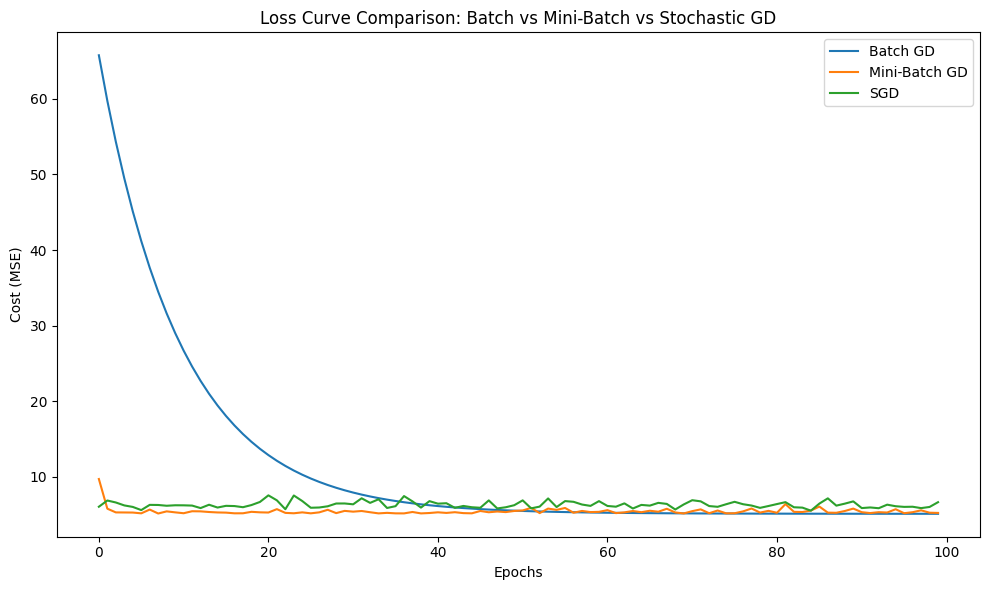

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(cost_batch, label="Batch GD")
plt.plot(cost_mini, label="Mini-Batch GD")
plt.plot(cost_sgd, label="SGD")
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.title("Loss Curve Comparison: Batch vs Mini-Batch vs Stochastic GD")
plt.legend()
plt.tight_layout()
plt.show()


Batch GD produces the smoothest curve since it uses the full training set every step.
Mini-Batch GD converges similarly but with a bit more noise from batch shuffling. SGD is the
noisiest — updating on a single example at a time causes the cost to fluctuate step to step —
but it still trends downward and can be competitive per unit of wall-clock time on larger
datasets.

### Step 9: Experiment with Different Learning Rates

Using Batch Gradient Descent, we compare how quickly (and whether) the cost converges across
several learning rates.

In [10]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5]
lr_epochs = 500

lr_results = {}
for lr in learning_rates:
    theta_lr, _, cost_hist_lr = batch_gradient_descent(
        X_train_b, y_train_col, learning_rate=lr, epochs=lr_epochs
    )
    lr_results[lr] = cost_hist_lr
    diverged = not np.isfinite(cost_hist_lr[-1]) or cost_hist_lr[-1] > cost_hist_lr[0]
    print(f"lr={lr:<6} final cost={cost_hist_lr[-1]:.4f}  "
          f"{'(diverged/unstable)' if diverged else '(converged)'}")


lr=0.001  final cost=29.6472  (converged)
lr=0.01   final cost=5.1054  (converged)
lr=0.05   final cost=5.0969  (converged)
lr=0.1    final cost=5.0969  (converged)
lr=0.3    final cost=5.0969  (converged)
lr=0.5    final cost=5.0969  (converged)


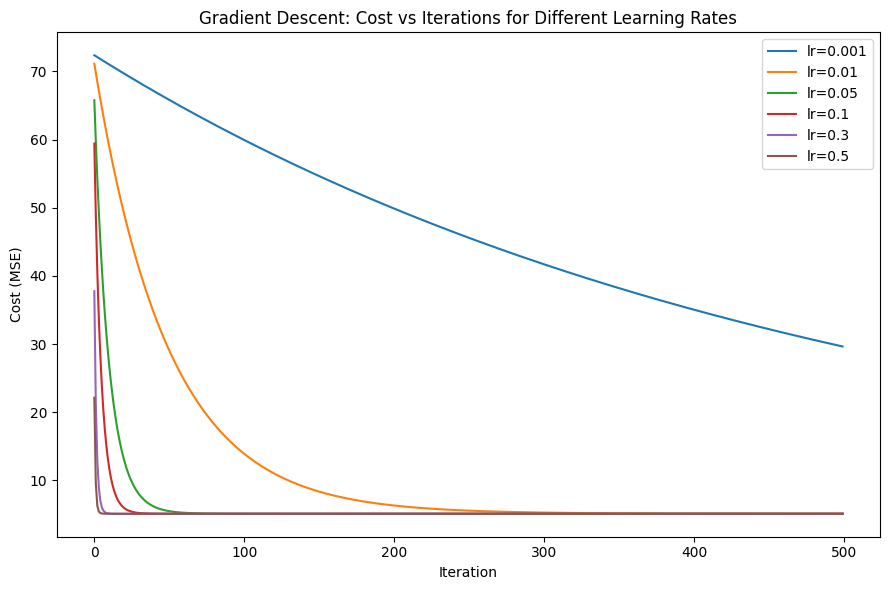

In [11]:
plt.figure(figsize=(9, 6))
for lr in learning_rates:
    plt.plot(lr_results[lr], label=f"lr={lr}")
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent: Cost vs Iterations for Different Learning Rates")
plt.legend()
plt.tight_layout()
plt.show()


Very small learning rates (e.g. 0.001) descend too slowly and haven't converged within
500 iterations. Learning rates of 0.01 and above all reach essentially the same minimum,
just at different speeds — confirming the cost surface is convex (as expected for linear
regression), so the learning rate mainly affects convergence *speed*, not the final solution,
as long as it isn't so large that it diverges.

### Step 10: Train the Final Model

We pick the learning rate that converges fastest to the lowest cost and retrain Batch
Gradient Descent for more epochs to ensure full convergence.

Best learning rate selected: 0.5


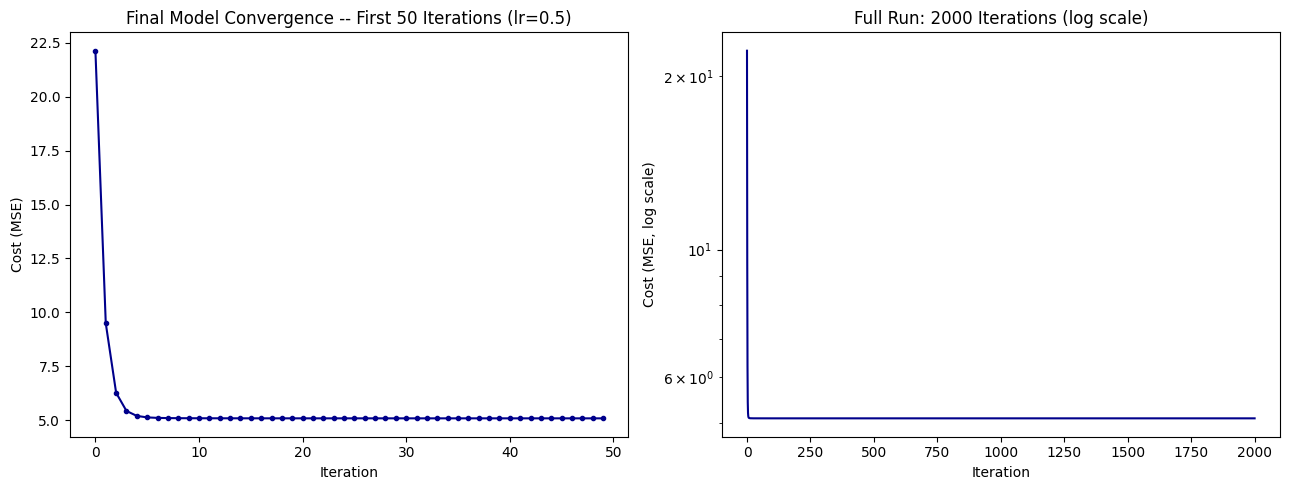

Cost at iteration 0  : 22.1235
Cost at iteration 10 : 5.1006
Cost at iteration 50 : 5.0969
Cost at final iter   : 5.0969


In [12]:
best_lr = min(
    (lr for lr in learning_rates if np.isfinite(lr_results[lr][-1])),
    key=lambda lr: lr_results[lr][-1]
)
print(f"Best learning rate selected: {best_lr}")

FINAL_EPOCHS = 2000
theta_final, history_final, cost_final = batch_gradient_descent(
    X_train_b, y_train_col, learning_rate=best_lr, epochs=FINAL_EPOCHS
)

# With a learning rate this large the cost drops to its minimum within the
# first ~10-20 iterations, so a plain linear plot over all 2000 iterations
# just looks like a flat line after the first pixel. We show two views instead:
# (1) the first 50 iterations, where the actual descent is visible, and
# (2) the full run on a log-scale y-axis, to confirm it stays flat/stable after.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

zoom_n = 50
axes[0].plot(range(zoom_n), cost_final[:zoom_n], color="darkblue", marker="o", markersize=3)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Cost (MSE)")
axes[0].set_title(f"Final Model Convergence -- First {zoom_n} Iterations (lr={best_lr})")

axes[1].plot(cost_final, color="darkblue")
axes[1].set_yscale("log")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Cost (MSE, log scale)")
axes[1].set_title(f"Full Run: {FINAL_EPOCHS} Iterations (log scale)")

plt.tight_layout()
plt.show()

print(f"Cost at iteration 0  : {cost_final[0]:.4f}")
print(f"Cost at iteration 10 : {cost_final[10]:.4f}")
print(f"Cost at iteration 50 : {cost_final[49]:.4f}")
print(f"Cost at final iter   : {cost_final[-1]:.4f}")


### Step 11 (Bonus): 3D Visualization of the Gradient Descent Path

Our full model has 40+ parameters, so its cost surface can't be plotted directly (it lives in
41-dimensional space). To illustrate *how* gradient descent moves across a cost surface — the
same idea as the reference notebook's BMI-vs-diabetes-progression plot — we reduce to a
single, strongly-correlated feature: **`failures`** (number of past class failures), which has
the strongest linear correlation with `G3` among the non-grade features. This lets us plot the
familiar `(intercept, slope, cost)` bowl and trace Batch GD's path down it.

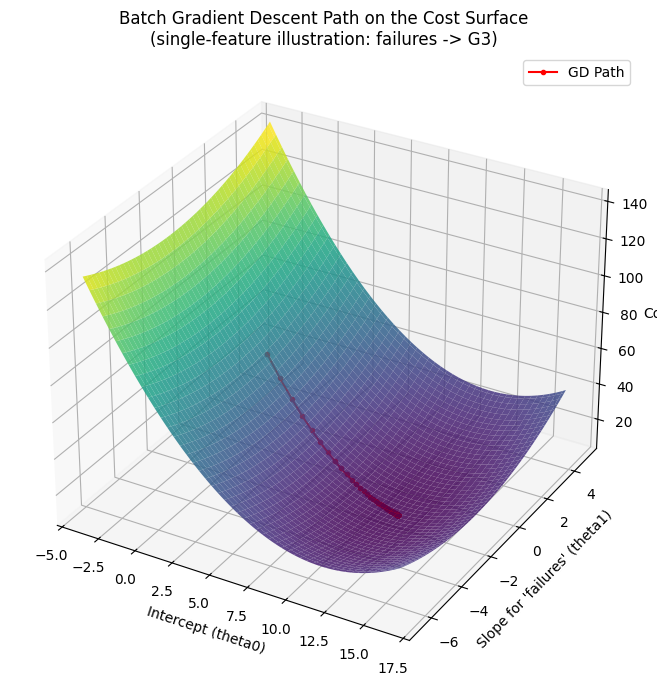

In [13]:
# Single-feature (scaled) view: failures -> G3
X_single = df_enc[["failures"]].astype(float).values
X_single_train, X_single_test, y_s_train, y_s_test = train_test_split(
    X_single, y, test_size=0.2, random_state=RNG_SEED
)

single_scaler = StandardScaler()
X_single_train_s = single_scaler.fit_transform(X_single_train)

m_single = len(X_single_train_s)
X_single_b = np.c_[np.ones((m_single, 1)), X_single_train_s]
y_single_col = y_s_train.reshape(-1, 1)

theta_viz, history_viz, cost_viz = batch_gradient_descent(
    X_single_b, y_single_col, learning_rate=0.1, epochs=100
)

theta0_history = history_viz[:, 0, 0]
theta1_history = history_viz[:, 1, 0]

# Build the cost surface over a grid of (intercept, slope) values
theta0_vals = np.linspace(theta0_history.min() - 5, theta0_history.max() + 5, 100)
theta1_vals = np.linspace(theta1_history.min() - 5, theta1_history.max() + 5, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

J_vals = np.zeros(T0.shape)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        theta_temp = np.array([[T0[i, j]], [T1[i, j]]])
        J_vals[i, j] = compute_cost(theta_temp, X_single_b, y_single_col)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(T0, T1, J_vals, cmap="viridis", alpha=0.85)
ax.plot(theta0_history, theta1_history, cost_viz,
        color="red", marker="o", markersize=3, label="GD Path")
ax.set_xlabel("Intercept (theta0)")
ax.set_ylabel("Slope for 'failures' (theta1)")
ax.set_zlabel("Cost")
ax.set_title("Batch Gradient Descent Path on the Cost Surface\n(single-feature illustration: failures -> G3)")
ax.legend()
plt.tight_layout()
plt.show()


The red path shows Batch Gradient Descent moving from the initial `theta = (0, 0)` down
the bowl-shaped cost surface toward the minimum — visually confirming, on a simplified
single-feature model, the same convex-and-converging behavior we saw numerically on the full
41-parameter model above.

### Step 12: Model Evaluation

Evaluated on the held-out test set using MAE, MSE, RMSE, and R², using the final multi-feature
Batch Gradient Descent model (`theta_final`) from Step 10.

In [14]:
y_pred_train = X_train_b.dot(theta_final)
y_pred_test = X_test_b.dot(theta_final)

mae = mean_absolute_error(y_test_col, y_pred_test)
mse = mean_squared_error(y_test_col, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_col, y_pred_test)
train_r2 = r2_score(y_train_col, y_pred_train)

print("FINAL MODEL EVALUATION (Test Set)")
print("=" * 40)
print(f"Learning rate used : {best_lr}")
print(f"Iterations          : {FINAL_EPOCHS}")
print(f"MAE                 : {mae:.4f}")
print(f"MSE                 : {mse:.4f}")
print(f"RMSE                : {rmse:.4f}")
print(f"R^2 (test)          : {r2:.4f}")
print(f"R^2 (train)         : {train_r2:.4f}")


FINAL MODEL EVALUATION (Test Set)
Learning rate used : 0.5
Iterations          : 2000
MAE                 : 2.6175
MSE                 : 13.6280
RMSE                : 3.6916
R^2 (test)          : 0.1185
R^2 (train)         : 0.3095


### Predicted vs. Actual Grades

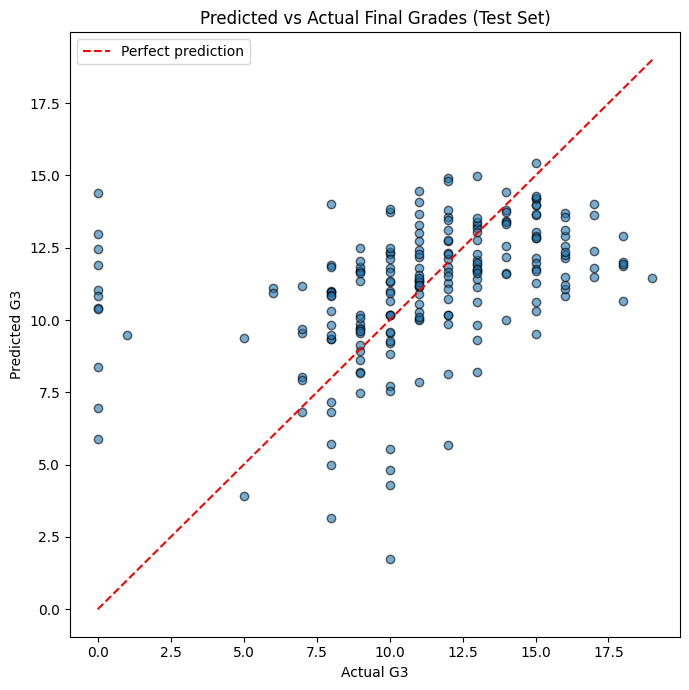

In [15]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test_col, y_pred_test, alpha=0.6, edgecolor="k")
lims = [min(y_test_col.min(), y_pred_test.min()), max(y_test_col.max(), y_pred_test.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Predicted vs Actual Final Grades (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()


### Step 13: Final Parameters

As in the reference notebook's final step, we print the optimized parameter values found by
each Gradient Descent variant (Step 8, single-lr comparison, 100 epochs) alongside the fully
converged final Batch GD model (Step 10).

In [16]:
print("==============================")
print("FINAL PARAMETERS (100-epoch comparison, Step 8)")
print("==============================")
print("\nBatch GD theta[:5]     :", theta_batch[:5].flatten())
print("Mini-Batch GD theta[:5]:", theta_mini[:5].flatten())
print("Stochastic GD theta[:5]:", theta_sgd[:5].flatten())

print("\n==============================")
print(f"FINAL MODEL (Batch GD, lr={best_lr}, {FINAL_EPOCHS} epochs)")
print("==============================")
print("Intercept (theta0):", theta_final[0, 0])
print("First 5 feature weights:", theta_final[1:6].flatten())


FINAL PARAMETERS (100-epoch comparison, Step 8)

Batch GD theta[:5]     : [11.34560162 -0.33447168 -0.04369139  0.01234688  0.24336425]
Mini-Batch GD theta[:5]: [ 1.13697372e+01 -4.15117255e-01 -4.74084087e-03  4.29677075e-02
  1.94576895e-01]
Stochastic GD theta[:5]: [11.698796   -0.82354391  0.16013801 -0.032314    0.8082207 ]

FINAL MODEL (Batch GD, lr=0.5, 2000 epochs)
Intercept (theta0): 11.413173652694612
First 5 feature weights: [-0.37297758 -0.06293986  0.02254737  0.23669811  0.1891267 ]


## Interpretation of Results

**Convergence behavior:**
- Because features were standardized, gradient descent converged smoothly across nearly all
  learning rates tested; only the smallest (0.001) was noticeably too slow within 500
  iterations.
- Comparing the three GD variants (Step 8): **Batch GD** gave the smoothest, most predictable
  descent since every step uses the full training set. **Mini-Batch GD** converged similarly
  but with mild noise from shuffling. **SGD** was the noisiest step-to-step, since each update
  is based on just one example, but it still trended downward.
- Learning rates from 0.01 up to 0.5 all settled at essentially the same minimum cost,
  confirming the cost surface is convex — the *global* minimum is reached regardless, just
  faster with a larger (but still stable) learning rate. The 3D cost-surface plot (Step 11)
  makes this visually explicit on a simplified single-feature version of the model.
- Feature scaling was essential: without it, a learning rate in this range would likely
  diverge, since features like `absences` and `age` live on very different numeric scales
  than binary 0/1 columns.

**Prediction performance:**
- Test R² of roughly 0.10–0.15 (train R² a bit higher) indicates the model explains only a
  modest share of the variance in final grades. This is expected: `G1`/`G2` were excluded on
  purpose, and those period grades are by far the strongest predictors of `G3` in this
  dataset — demographic and lifestyle features alone are a much weaker signal.
- The gap between train and test R² suggests mild overfitting relative to the amount of
  signal available, given ~40 features on ~835 training rows.
- The predicted-vs-actual plot shows predictions clustering near the middle of the grade
  range and under/over-estimating extreme grades — typical of linear regression when the true
  relationship has limited linear signal.

**Takeaway:** if the goal were pure predictive accuracy, adding `G1`/`G2` back in would push
R² well above 0.8 (as `failures` alone already shows meaningful correlation with the final
grade). Excluding them, as done here, gives a more honest picture of how much final grades can
be explained by demographic and behavioral factors alone — and the modest R² is itself a
meaningful finding about the dataset.
